In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [23]:
df = pd.read_csv("results/spec_v2/training_data_with_predictions.csv")

In [24]:
def get_avg_error(df: pd.DataFrame) -> float:
    eps = 1e-8
    return (abs(df["Predicted CPI"] - df["cpi"]) / (df["cpi"] + eps)).mean() * 100

In [25]:
plots_dir = "results/spec_v2/plots"
os.makedirs(plots_dir, exist_ok=True)

## Error Analysis Per Benchmark 

In [26]:
total_percent_error = get_avg_error(df)
print(f"Total percent error for all benchmarks: {total_percent_error}")

Total percent error for all benchmarks: 2.20367715594492


In [27]:
benchmark_errors = {}
for benchmark in df["benchmark"].unique():
    df_benchmark = df[df["benchmark"] == benchmark]
    total_percent_error = get_avg_error(df_benchmark)
    benchmark_errors[benchmark] = total_percent_error

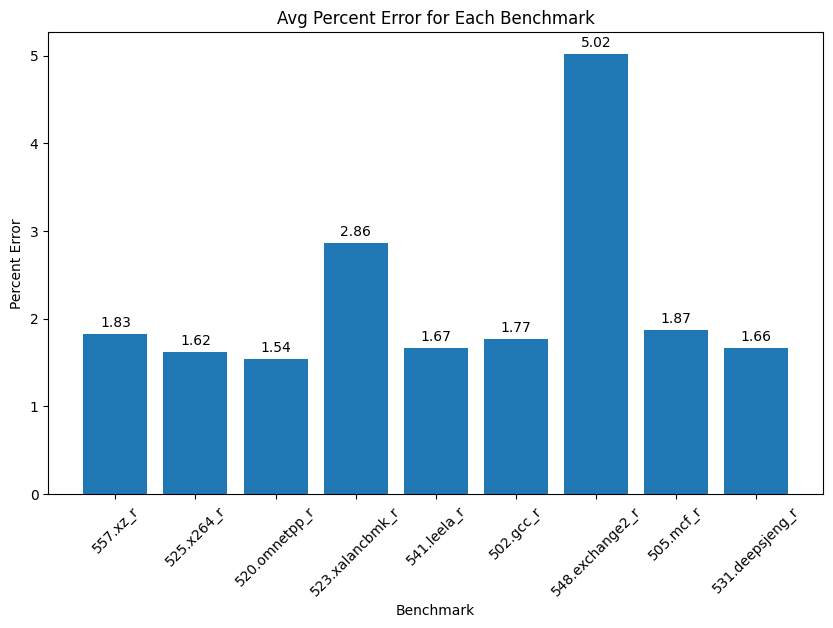

In [28]:
fig = plt.figure(figsize=(10, 6))
plt.bar(benchmark_errors.keys(), benchmark_errors.values())
plt.xlabel("Benchmark")
plt.ylabel("Percent Error")
plt.xticks(rotation=45)
for i, (benchmark, error) in enumerate(benchmark_errors.items()):
    plt.text(i, error + 0.05, f"{error:.2f}", ha='center', va='bottom')
plt.title("Avg Percent Error for Each Benchmark")
plt.show()
fig.savefig(os.path.join(plots_dir, "spec_benchmark_errors.png"), bbox_inches='tight')

## Error Analysis Per Config 

In [18]:
PARAM_VALUES = {
    "int_reg_issue_width": list(range(1, 8 + 1)),
    "int_mult_div_issue_width": list(range(1, 8 + 1)),
    "fp_reg_issue_width": list(range(1, 8 + 1)),
    "fp_mult_div_issue_width": list(range(1, 8 + 1)),
    "read_port_issue_width": list(range(1, 8 + 1)),
    "rdwr_port_issue_width": list(range(1, 8 + 1)),
    "simd_unit_issue_width": [1],
    "fetch_width": list(range(1, 12 + 1)),
    "decode_width": list(range(1, 12 + 1)),
    "rename_width": list(range(1, 12 + 1)),
    "commit_width": list(range(1, 12 + 1)),
    "rob_size": list(range(1, 1024 + 1)),
    "lq_entries": list(range(1, 256 + 1)),
    "sq_entries": list(range(1, 256 + 1)),
    "branch_predictor": ["local", "tage"],
    "l1d_size": ["16KiB", "32KiB", "64KiB", "128KiB", "256KiB"],
    "l1i_size": ["16KiB", "32KiB", "64KiB", "128KiB", "256KiB"],
    "l2_size": ["512KiB", "1MiB", "2MiB", "4MiB"],
    "max_icache_fills": list(range(1, 32 + 1)),
    "stride_prefetcher_degree": [0, 4],
}

In [19]:
param_columns = list(PARAM_VALUES.keys())

In [20]:
param_columns_wo_bp = ['commit_width', 'decode_width', 'fetch_width',
       'fp_mult_div_issue_width', 'fp_reg_issue_width',
       'int_mult_div_issue_width', 'int_reg_issue_width', 'l1d_size',
       'l1i_size', 'l2_size', 'lq_entries', 'max_icache_fills',
       'rdwr_port_issue_width', 'read_port_issue_width', 'rename_width',
       'rob_size', 'simd_unit_issue_width', 'sq_entries',
       'stride_prefetcher_degree']

In [21]:
os.makedirs(os.path.join(plots_dir, "param_errors"), exist_ok=True)
for param in param_columns_wo_bp:
    param_errors = {}
    for value in PARAM_VALUES[param]:
        df_param = df[df[param] == value]
        param_errors[value] = get_avg_error(df_param)
    fig = plt.figure(figsize=(10, 6))
    plt.bar(param_errors.keys(), param_errors.values())
    plt.xlabel(param)
    plt.ylabel("Percent Error")
    plt.title(f"Error Analysis for {param}")
    fig.savefig(os.path.join(plots_dir, "param_errors", f"{param}_errors.png"))
    plt.close(fig)
    

In [22]:
os.makedirs(os.path.join(plots_dir, "param_errors_per_benchmark"), exist_ok=True)
benchmarks = sorted(df["benchmark"].unique())
for param in param_columns_wo_bp:
    values = PARAM_VALUES[param]
    # errors[benchmark][i] = avg % error for that param value index i
    errors_by_benchmark = {b: [] for b in benchmarks}
    for value in values:
        df_param = df[df[param] == value]
        for benchmark in benchmarks:
            df_b = df_param[df_param["benchmark"] == benchmark]
            errors_by_benchmark[benchmark].append(get_avg_error(df_b))

    x = np.arange(len(values))
    n_b = len(benchmarks)
    width = 0.8 / max(n_b, 1)

    fig, ax = plt.subplots(figsize=(max(10, len(values) * 0.35), 6))
    for i, benchmark in enumerate(benchmarks):
        offset = (i - (n_b - 1) / 2) * width
        ax.bar(x + offset, errors_by_benchmark[benchmark], width, label=benchmark)

    ax.set_xticks(x)
    ax.set_xticklabels(values, rotation=45, ha="right")
    ax.set_xlabel(param)
    ax.set_ylabel("Percent Error")
    ax.set_title(f"Percent error by {param} (by benchmark)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig(
        os.path.join(plots_dir, "param_errors_per_benchmark", f"{param}_errors.png"),
        bbox_inches="tight",
    )
    plt.close(fig)


# OOD Analysis

In [7]:
sweep_dir = "sweep_results/ood_peregrine"

In [8]:
summary_file = os.path.join(sweep_dir, "summary.txt")
with open(summary_file, "r") as f:
    summary = f.read()

In [9]:
ood_benchmark_errors = {}
bmark = ""
for line in summary.split("\n"):
    if bmark:
        ood_benchmark_errors[bmark] = float(line.split(": ")[1].split("%")[0].strip())
        bmark = ""
    elif "Out-of-distribution benchmark: " in line:
        bmark = line.split(": ")[1].strip()

print(ood_benchmark_errors)

{'branch_storm': 368.93, 'collatz': 58.87, 'dhrystone': 47.66, 'linpack': 103.84, 'sieve': 41.23, 'sparse': 5300.04, 'towers': 174.73, 'whetstone': 37.26}


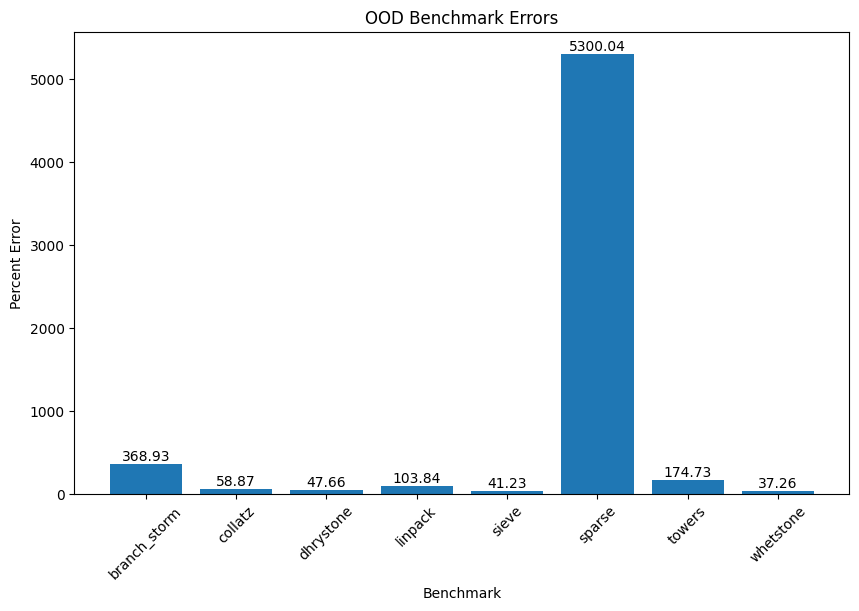

In [10]:
fig = plt.figure(figsize=(10, 6))
plt.bar(ood_benchmark_errors.keys(), ood_benchmark_errors.values())
for i, (benchmark, error) in enumerate(ood_benchmark_errors.items()):
    plt.text(i, error + 0.05, f"{error:.2f}", ha='center', va='bottom')
plt.xlabel("Benchmark")
plt.xticks(rotation=45)
plt.ylabel("Percent Error")
plt.title("OOD Benchmark Errors")
plt.show()
fig.savefig(os.path.join(sweep_dir, "ood_benchmark_errors.png"), bbox_inches='tight')